In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\user\Desktop\Machine Anomaly Detection System\cement_anomaly_dataset.csv")

In [3]:
df.head()

,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure
0,1474.835708,3.324475670392464,143.427611,194.007132,-10.0
1,1443.086785,1.5757161863639682,118.586575,271.912910,-10.0
2,1937.305949,9.367959265243611,88.654613,245.169507,-10.0
3,1526.151493,2.0046092334709056,99.170428,238.669450,-10.0
4,1438.292331,2.238077754903238,114.860238,280.702769,-10.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   kiln_temperature  100000 non-null  float64
 1   mill_vibration    100000 non-null  object 
 2   motor_current     100000 non-null  float64
 3   feed_rate         98000 non-null   float64
 4   gas_pressure      100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


## Data Wrangling

In [5]:
df.isnull().sum()

kiln_temperature       0
mill_vibration         0
motor_current          0
feed_rate           2000
gas_pressure           0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kiln_temperature  98000 non-null  float64
 1   mill_vibration    98000 non-null  object 
 2   motor_current     98000 non-null  float64
 3   feed_rate         98000 non-null  float64
 4   gas_pressure      98000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 4.5+ MB


In [8]:
df.duplicated().any()

np.False_

In [9]:
df.describe()

,kiln_temperature,motor_current,feed_rate,gas_pressure
count,98000.000000,98000.000000,98000.000000,98000.000000
mean,1472.282117,119.304514,250.013863,4.981196
std,109.622925,15.225597,40.064635,1.089427
min,1226.719807,53.791711,77.481083,-10.000000
25%,1418.315228,109.035468,222.832405,4.313506
50%,1453.359834,119.257482,250.119266,4.991000
75%,1490.487367,129.595691,276.932578,5.672145
max,2138.575699,183.290495,403.050207,9.301848


# looking for anomalies

Text(0.5, 1.0, 'Kiln Temperature Distribution')

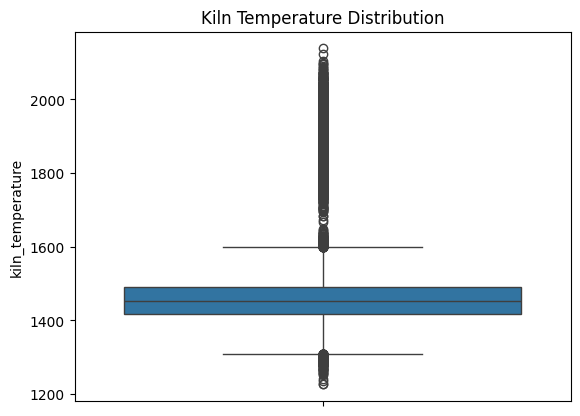

In [10]:
sns.boxplot(data=df['kiln_temperature'])
plt.title("Kiln Temperature Distribution")

#### we can use quantiles to get to look at our anomalees

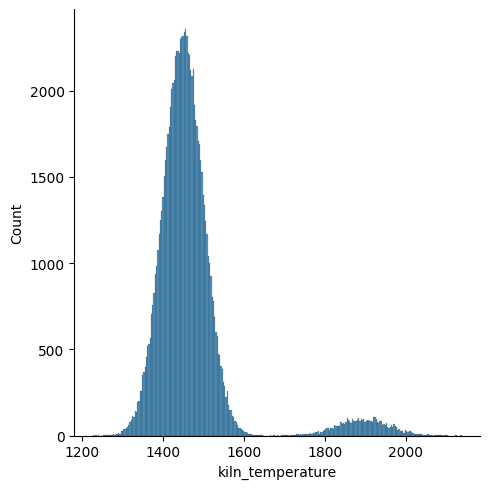

In [11]:
sns.displot(data=df['kiln_temperature'])

In [12]:
Q1=df['kiln_temperature'].quantile(0.25)
Q3=df['kiln_temperature'].quantile(0.75)

In [13]:
IQR=Q3-Q1

In [14]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [15]:
df[df['kiln_temperature']<lower_bound].shape

(243, 5)

In [16]:
df[df['kiln_temperature']>upper_bound].shape


(5035, 5)

#### we have 5000 values above the 75% quartile of the data,which can also be used for the anomalee detection


In [17]:
df['mill_vibration'].info()

<class 'pandas.core.series.Series'>
Index: 98000 entries, 0 to 99999
Series name: mill_vibration
Non-Null Count  Dtype 
--------------  ----- 
98000 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [18]:
pd.to_numeric(df['mill_vibration'],errors='coerce').astype(float)

0        3.324476
1        1.575716
2        9.367959
3        2.004609
4        2.238078
           ...   
99995    1.488361
99996    2.952523
99997    2.628016
99998    3.184538
99999    1.648042
Name: mill_vibration, Length: 98000, dtype: float64

In [19]:
df['mill_vibration'].astype(str).str.contains(r'[^0-9]').unique()

array([ True])

In [20]:
non_numeric=pd.to_numeric(df['mill_vibration'],errors='coerce').isna()

In [21]:
df_non_numeric=df[non_numeric]

In [22]:
print(df_non_numeric)

     kiln_temperature mill_vibration  motor_current   feed_rate  gas_pressure
200       1467.889368    sensor_fail     119.312840  207.464367      5.579455
201       1478.039226    sensor_fail     121.785750  268.832364      5.013322
202       1504.152562    sensor_fail     118.509393  264.273328      4.575648
203       1502.690103    sensor_fail     114.449639  254.327343      6.146025
204       1381.116532    sensor_fail     113.817560  259.616294      5.278466
205       1833.701755    sensor_fail      82.048835  226.349039      5.010417
206       1475.751763    sensor_fail     115.842772  251.214037      4.684233
207       1475.689298    sensor_fail     114.401988  225.445232      5.522291
208       1475.752384    sensor_fail     109.823423  264.163748      5.615386
209       1642.636575    sensor_fail     110.616644  284.609467      6.460729
210       1478.544526    sensor_fail     120.609396  189.314272      4.579922
211       1506.778282    sensor_fail     114.279171  205.393212 

In [23]:
df['mill_vibration']=pd.to_numeric(df['mill_vibration'],errors='coerce')

In [24]:
df['mill_vibration'].isnull().sum()

np.int64(59)

In [25]:
df.dropna(subset=['mill_vibration'],inplace=True)

In [26]:
df['mill_vibration'].isnull().sum()

np.int64(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97941 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kiln_temperature  97941 non-null  float64
 1   mill_vibration    97941 non-null  float64
 2   motor_current     97941 non-null  float64
 3   feed_rate         97941 non-null  float64
 4   gas_pressure      97941 non-null  float64
dtypes: float64(5)
memory usage: 4.5 MB


In [28]:
df=df.round(2)

#### looking at the distribution of data in the table

Text(0.5, 1.0, 'Distribution Of Mill Vibration')

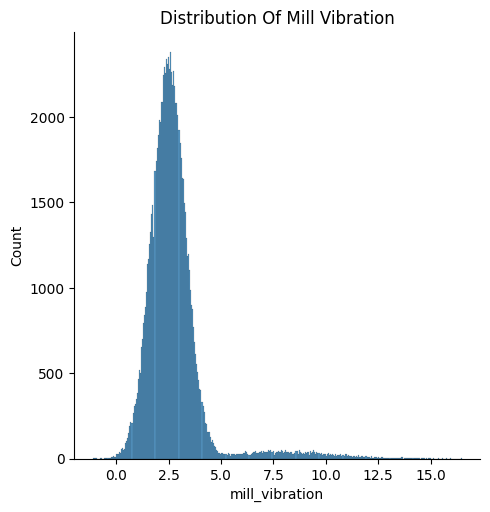

In [29]:
figsize=(12,10)
sns.displot(data=df['mill_vibration'])
plt.title("Distribution Of Mill Vibration")

Text(0.5, 1.0, 'Distribution Of Mill Vibration')

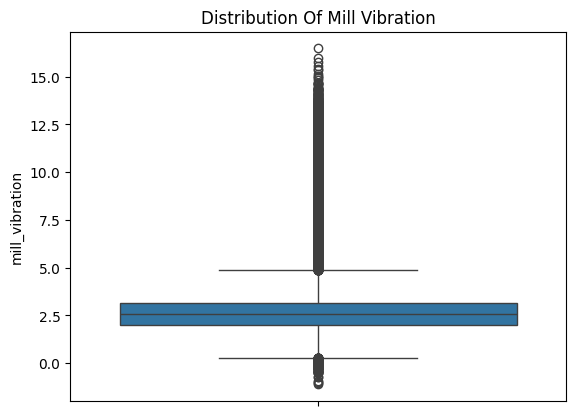

In [30]:
figsize=(18,16)
sns.boxplot(data=df['mill_vibration'])
plt.title("Distribution Of Mill Vibration")

In [31]:
df.describe()

,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure
count,97941.000000,97941.000000,97941.000000,97941.000000,97941.000000
mean,1472.279044,2.771614,119.305199,250.016478,4.981153
std,109.631103,1.518286,15.225233,40.063224,1.089591
min,1226.720000,-1.110000,53.790000,77.480000,-10.000000
25%,1418.320000,1.990000,109.040000,222.840000,4.310000
50%,1453.340000,2.550000,119.260000,250.120000,4.990000
75%,1490.490000,3.140000,129.600000,276.940000,5.670000
max,2138.580000,16.480000,183.290000,403.050000,9.300000


In [32]:
df[df['mill_vibration']<0].count()

kiln_temperature    78
mill_vibration      78
motor_current       78
feed_rate           78
gas_pressure        78
dtype: int64

In [33]:
df['negative_mill_vibration']=(df['mill_vibration']<0).astype(int)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97941 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   kiln_temperature         97941 non-null  float64
 1   mill_vibration           97941 non-null  float64
 2   motor_current            97941 non-null  float64
 3   feed_rate                97941 non-null  float64
 4   gas_pressure             97941 non-null  float64
 5   negative_mill_vibration  97941 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 5.2 MB


In [35]:
df.head()


,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure,negative_mill_vibration
0,1474.84,3.32,143.43,194.01,-10.0,0
1,1443.09,1.58,118.59,271.91,-10.0,0
2,1937.31,9.37,88.65,245.17,-10.0,0
3,1526.15,2.00,99.17,238.67,-10.0,0
4,1438.29,2.24,114.86,280.70,-10.0,0


Text(0.5, 1.0, 'Distribution Of Motor Current')

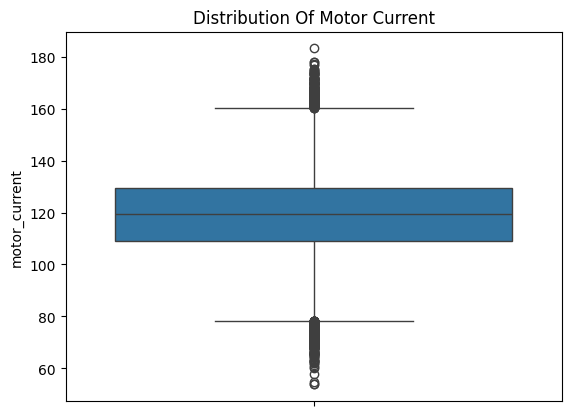

In [36]:
figsize=(12,10)
sns.boxplot(data=df['motor_current'])
plt.title("Distribution Of Motor Current")

Text(0.5, 1.0, 'Distribution Of Motor Current')

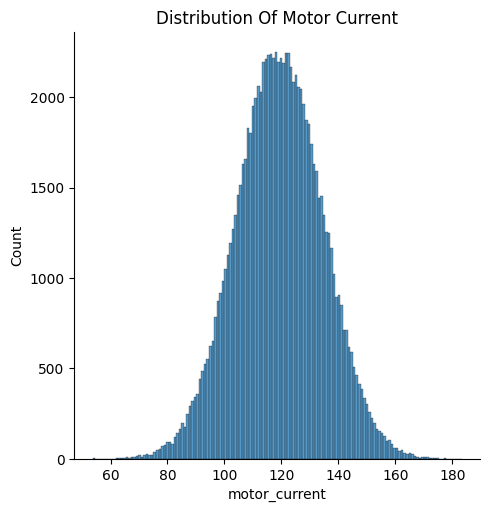

In [37]:
figsize=(12,10)
sns.displot(data=df['motor_current'])
plt.title("Distribution Of Motor Current")

In [38]:
df

,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure,negative_mill_vibration
0,1474.84,3.32,143.43,194.01,-10.00,0
1,1443.09,1.58,118.59,271.91,-10.00,0
2,1937.31,9.37,88.65,245.17,-10.00,0
3,1526.15,2.00,99.17,238.67,-10.00,0
4,1438.29,2.24,114.86,280.70,-10.00,0
...,...,...,...,...,...,...
99995,1438.74,1.49,113.52,227.82,6.33,0
99996,1421.51,2.95,109.69,157.34,4.89,0
99997,1470.46,2.63,109.81,283.26,4.76,0
99998,1439.45,3.18,103.92,268.50,4.20,0


Text(0.5, 1.0, 'Distribution Of Motor Current')

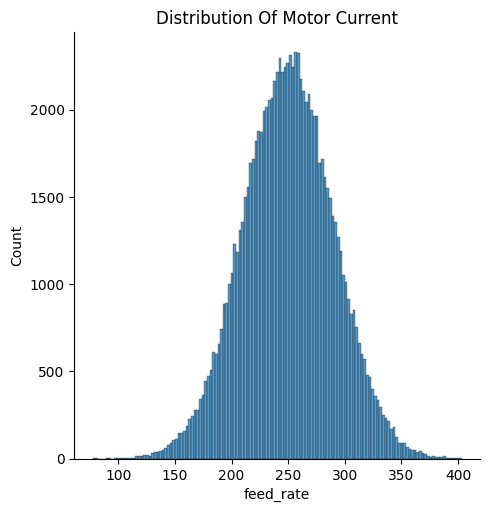

In [39]:
figsize=(12,10)
sns.displot(data=df['feed_rate'])
plt.title("Distribution Of Motor Current")

Text(0.5, 1.0, 'Distribution Of Motor Current')

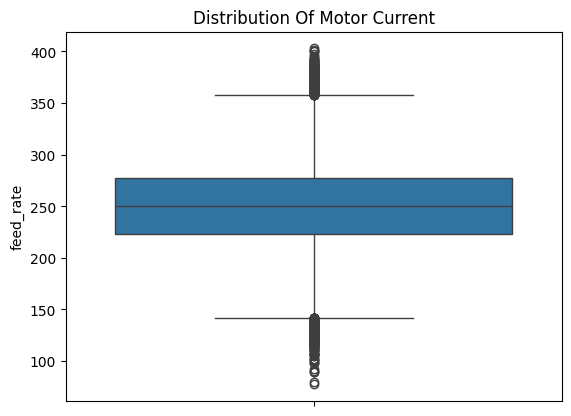

In [40]:
figsize=(12,10)
sns.boxplot(data=df['feed_rate'])
plt.title("Distribution Of Motor Current")

In [41]:
df['gas_pressure']<0

0         True
1         True
2         True
3         True
4         True
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: gas_pressure, Length: 97941, dtype: bool

In [42]:
df['negative_gas_pressure_reading']=(df['gas_pressure']<0).astype(int)

In [43]:
df.head()

,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure,negative_mill_vibration,negative_gas_pressure_reading
0,1474.84,3.32,143.43,194.01,-10.0,0,1
1,1443.09,1.58,118.59,271.91,-10.0,0,1
2,1937.31,9.37,88.65,245.17,-10.0,0,1
3,1526.15,2.00,99.17,238.67,-10.0,0,1
4,1438.29,2.24,114.86,280.70,-10.0,0,1


#### done with the cleaning of the data now we need to save the data and begin modeling using isolation forest

In [44]:
corr=df[['kiln_temperature','mill_vibration','motor_current','feed_rate','gas_pressure']]

In [46]:
df

,kiln_temperature,mill_vibration,motor_current,feed_rate,gas_pressure,negative_mill_vibration,negative_gas_pressure_reading
0,1474.84,3.32,143.43,194.01,-10.00,0,1
1,1443.09,1.58,118.59,271.91,-10.00,0,1
2,1937.31,9.37,88.65,245.17,-10.00,0,1
3,1526.15,2.00,99.17,238.67,-10.00,0,1
4,1438.29,2.24,114.86,280.70,-10.00,0,1
...,...,...,...,...,...,...,...
99995,1438.74,1.49,113.52,227.82,6.33,0,0
99996,1421.51,2.95,109.69,157.34,4.89,0,0
99997,1470.46,2.63,109.81,283.26,4.76,0,0
99998,1439.45,3.18,103.92,268.50,4.20,0,0


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import SelectKBest,f_classif

In [49]:
numericals=['kiln_temperature','mill_vibration','motor_current','feed_rate','gas_pressure']

In [86]:
x=df[numericals]

In [87]:
preprocessing=ColumnTransformer([
    ('std',StandardScaler(),numericals)
])

In [88]:
iso=IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

In [89]:
iso_pipeline=Pipeline([
    ('preprocessing',preprocessing),
    ('iso',iso)
])

In [90]:
iso_pipeline.fit(x)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('iso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [91]:
preds=iso_pipeline.predict(x)

In [92]:
preds

array([ 1,  1, -1, ...,  1,  1,  1])

In [93]:
df['anomaly']=preds

In [94]:
df['anomaly']=np.where(preds==-1,1,0)

In [95]:
df['anomaly'].value_counts()

anomaly
0    95982
1     1959
Name: count, dtype: int64

In [98]:
import joblib

In [99]:
joblib.dump(iso_pipeline,'anomaly_model.pkl')

['anomaly_model.pkl']

In [109]:
scores=iso_pipeline.decision_function(x)

In [110]:
import mlflow
import mlflow.sklearn



In [111]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Machine Maintenance Anomaly Detection")

<Experiment: artifact_location='mlflow-artifacts:/423153316910345774', creation_time=1773948884760, experiment_id='423153316910345774', last_update_time=1773948884760, lifecycle_stage='active', name='Machine Maintenance Anomaly Detection', tags={}>

In [112]:
anomaly_detection_model=joblib.load('anomaly_model.pkl')

In [115]:
with mlflow.start_run(run_name="anomaly_detection_model"):
    mlflow.log_param("model_file","anomaly_model.pkl")
    mlflow.log_param("model_type","learning")
    mlflow.log_param("contamination",0.02)
    mlflow.log_param("n_estimators",200)
    mlflow.log_metric("num_anomalies",(preds==-1).sum())
    mlflow.log_metric("num_non-anomaies",(preds==1).sum())
    mlflow.log_metric("avg_anomaly_score",scores.mean())
    mlflow.sklearn.log_model(anomaly_detection_model,"model")
mlflow.end_run()

2026/03/19 22:51:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/03/19 22:51:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run anomaly_detection_model at: http://127.0.0.1:5000/#/experiments/423153316910345774/runs/7fc978795dab471587d124e0b1307317.
2026/03/19 22:51:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/423153316910345774.
